In [19]:
import pandas as pd    
import matplotlib.pyplot as plt              
import numpy as np      
import seaborn as sns

In [20]:
df=pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


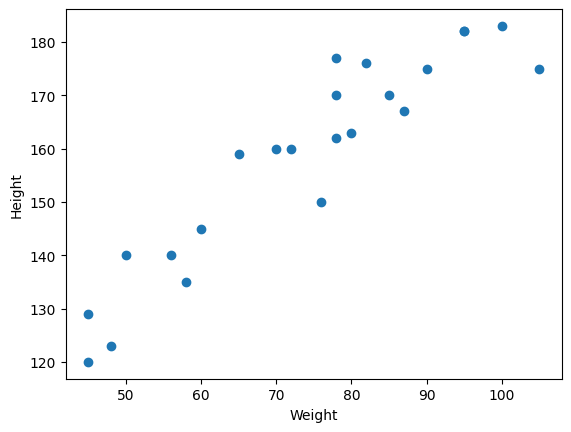

In [21]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.show()

In [22]:
X=df.iloc[:,:-1]
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [23]:
y=df.iloc[:,-1]
y.head()

0    120
1    135
2    123
3    145
4    160
Name: Height, dtype: int64

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [25]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()


In [26]:
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

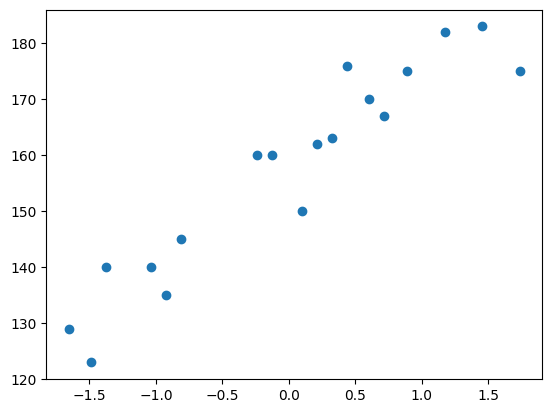

In [27]:
plt.scatter(X_train,y_train)

In [28]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()

In [29]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [30]:
lr.coef_

array([17.03440872])

In [31]:
lr.intercept_

np.float64(157.5)

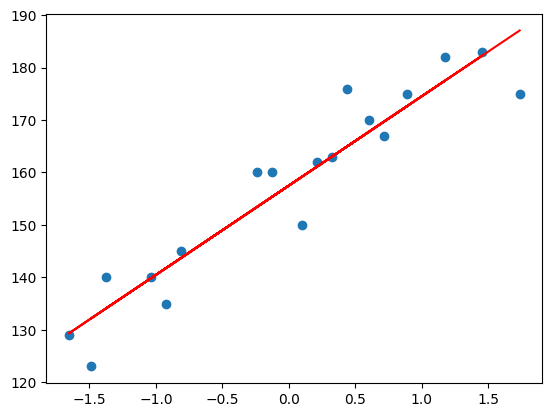

In [35]:
plt.scatter(X_train,y_train)
plt.plot(X_train,lr.predict(X_train),'r')

In [36]:
y_pred=lr.predict(X_test)

In [37]:
y_pred,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

In [38]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2__score=r2_score(y_test,y_pred)

In [39]:
mse,mae,r2__score


(109.77592599051664, 9.822657814519232, 0.776986986042344)

In [40]:
(1-(1-r2__score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1))

0.7026493147231252

In [41]:
# new data point of weight is 80
scaled_weight=scaler.transform([[80]])

/Users/ramrekhayadav/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [42]:
scaled_weight

array([[0.32350772]])

In [43]:
lr.predict(scaled_weight)

array([163.01076266])

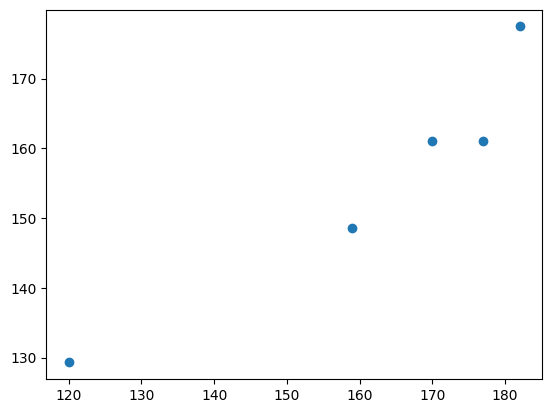

In [44]:
plt.scatter(y_test,y_pred)

In [45]:
resudials=y_test-y_pred
resudials

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

/var/folders/k6/jx95ypzx09jb1dr13vzmb1180000gn/T/ipykernel_15744/2902991944.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(resudials,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

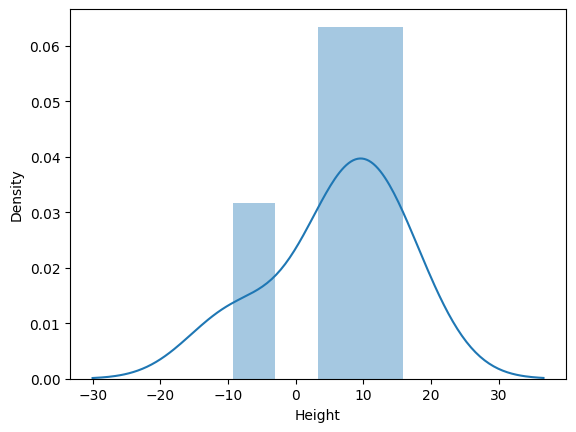

In [47]:
sns.distplot(resudials,kde=True)